In [1]:
import os
# Asegurar que el notebook se ejecuta desde la raíz del proyecto para que las rutas relativas coincidan
if os.path.basename(os.getcwd()) == 'examples':
    os.chdir('..')
print(f"Directorio actual: {os.getcwd()}")

Directorio actual: c:\Users\juanc\Desktop\TFM\TFM-Juan Carlos\Software\SAREnv


# SAREnv: Pruebas Rápidas - Entorno Casa de Campo

Este notebook permite ejecutar de forma secuencial y rápida las simulaciones de Búsqueda y Rescate (SAR) en el entorno de la Casa de Campo. 

**Objetivo de Integración:** 
Actualmente llamamos a los algoritmos "baseline" del entorno (Greedy, Spiral, Lawnmower, etc.). La arquitectura del software está preparada para que, en el futuro, nuestros sistemas de planificación propios se integren como una nueva clase bajo `sarenv/core/planners` (o similar) y puedan ser importados y evaluados exactamente con este mismo pipeline.

## 1. Generación del Mapa y Probabilidades
Primero generamos el mapa base de la Casa de Campo (si no está cacheado), descargando los datos de OpenStreetMap y generando la matriz de probabilidades (Heatmap).

In [2]:
import os

# Comprobamos si la carpeta ya existe para no repetir la generación pesada (30 mins)
if not os.path.exists("resultados_casa_de_campo"):
    print("Generando mapa desde cero... Esto puede tardar bastante.")
    from examples.generar_casa_de_campo import generar_casa_de_campo
    generar_casa_de_campo()
    print("✅ Mapa de Casa de Campo y probabilidades listos.")
else:
    print("⏭️ El mapa de Casa de Campo YA ESTÁ GENERADO en disco. Pasando al siguiente paso...")

⏭️ El mapa de Casa de Campo YA ESTÁ GENERADO en disco. Pasando al siguiente paso...


## 1.1 Generación de Entorno por Punto LKP
Generamos también el entorno a partir de un único punto central (PLS - Point Last Seen).

In [3]:
import os

# Al igual que antes, comprobamos si el mapa radial ya está descargado en disco
if not os.path.exists("resultados_casa_de_campo_punto"):
    print("Generando mapa radial expansivo desde cero... Sé paciente, tardará un rato.")
    from examples.generar_casa_de_campo_punto import generar_por_punto
    generar_por_punto()
    print("✅ Mapa de Casa de Campo por Punto LKP listo.")
else:
    print("⏭️ El mapa de Casa de Campo por Punto LKP YA ESTÁ GENERADO en disco. Saltando generación...")

⏭️ El mapa de Casa de Campo por Punto LKP YA ESTÁ GENERADO en disco. Saltando generación...


## 2. Ejecución de Búsqueda: Estrategia de Polígono (Confinada)
Ejecutamos los planificadores obligándolos a barrer el área delimitada de la Casa de Campo. 
*Ideal para evaluar tamaños de búsqueda pre-acotados (ej. `medium`, `xlarge`) con presupuestos de batería altos.*

In [4]:
# Evaluamos los algoritmos con la configuración de Polígono
from examples.evaluar_casa_de_campo import evaluar_casa_de_campo
evaluar_casa_de_campo()

print("Evaluación de Polígono finalizada. Resultados guardados en la carpeta de resultados.")

c:\Users\juanc\Desktop\TFM\TFM-Juan Carlos\Software\SAREnv\tfm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-30 12:05:09,988 - INFO - --- Iniciando Evaluación en la Casa de Campo --- (evaluar_casa_de_campo.py:19)
2026-04-30 12:05:09,990 - INFO - Loading datasets for sizes: ['large', 'xlarge'] (evaluator.py:571)
2026-04-30 12:05:09,993 - INFO - Attempting to generate dataset for size: 'large' (loading.py:165)
2026-04-30 12:05:09,995 - INFO - Loading master dataset from disk for the first time... (loading.py:100)
2026-04-30 12:05:10,635 - INFO - Loaded metadata: center=(-3.752500000000001, 40.417500000000004), resolution=20 m/bin (loading.py:111)
2026-04-30 12:05:11,449 - INFO - Loaded master probability map with shape (252, 277) (loading.py:127)
2026-04-30 12:05:12,609 - INFO - Clipped features to 31539 i

Evaluación de Polígono finalizada. Resultados guardados en la carpeta de resultados.


## 3. Ejecución de Búsqueda: Estrategia de Punto LKP (Expansión Radial)
Ejecutamos los algoritmos simulando un escenario donde solo conocemos el Último Punto Conocido (LKP - Last Known Position) y el área de búsqueda se va expandiendo progresivamente.

In [5]:
# Evaluamos los algoritmos con la configuración de Punto Central
from examples.evaluar_casa_de_campo_punto import evaluar_por_punto
evaluar_por_punto()

print("Evaluación Radial finalizada.")

2026-04-30 12:21:45,804 - INFO - --- Iniciando Evaluación desde Punto Central (LKP) --- (evaluar_casa_de_campo_punto.py:19)
2026-04-30 12:21:45,808 - INFO - Loading datasets for sizes: ['small', 'medium', 'large', 'xlarge'] (evaluator.py:571)
2026-04-30 12:21:45,810 - INFO - Attempting to generate dataset for size: 'small' (loading.py:165)
2026-04-30 12:21:45,812 - INFO - Loading master dataset from disk for the first time... (loading.py:100)
2026-04-30 12:21:50,781 - INFO - Loaded metadata: center=(-3.7337, 40.4187), resolution=20 m/bin (loading.py:111)
2026-04-30 12:21:56,561 - INFO - Loaded master probability map with shape (989, 990) (loading.py:127)
2026-04-30 12:21:56,913 - INFO - Clipped features to 1172 items for size 'small'. (loading.py:189)
2026-04-30 12:21:56,916 - INFO - Final heatmap for size 'small' has a probability sum of 0.0339 (loading.py:227)
2026-04-30 12:21:56,919 - INFO - Calculated feature type probabilities: {'brush': 7.689163123325957e-06, 'drainage': 3.015210

Evaluación Radial finalizada.


## 4. Visualización Rápida de Resultados
Cargamos uno de los PDFs generados para ver las trayectorias directamente aquí dentro del Notebook sin tener que ir buscando los archivos manualmente por las carpetas.

In [8]:
import os
from IPython.display import IFrame, display

# Puedes elegir qué visualización cargar cambiando estas rutas
ruta_poligono = "resultados_casa_de_campo/paths_plots/Greedy_casa_de_campo_ruta_medium.pdf"
ruta_punto = "resultados_casa_de_campo_punto/paths_plots/Greedy_punto_medium_3drones_250000m.pdf"

print("Visualización de Ruta: Estrategia de Polígono")
if os.path.exists(ruta_poligono):
    display(IFrame(ruta_poligono, width=900, height=500))
else:
    print(f"No se encontró: {ruta_poligono}")

print("\nVisualización de Ruta: Estrategia de Punto LKP")
if os.path.exists(ruta_punto):
    display(IFrame(ruta_punto, width=900, height=500))
else:
    print(f"No se encontró: {ruta_punto}")

Visualización de Ruta: Estrategia de Polígono



Visualización de Ruta: Estrategia de Punto LKP


## 5. Resultados Estadísticos (Casa de Campo)
Como hemos evaluado el rendimiento en los pasos anteriores, los algoritmos ya han generado sus propias gráficas comparativas con las estadísticas de éxito dentro de tu carpeta `resultados_casa_de_campo/graphs`. Las extraemos y mostramos directamente aquí para tus pruebas locales.

============== RESULTADOS ESTRATEGIA POLÍGONO ==============


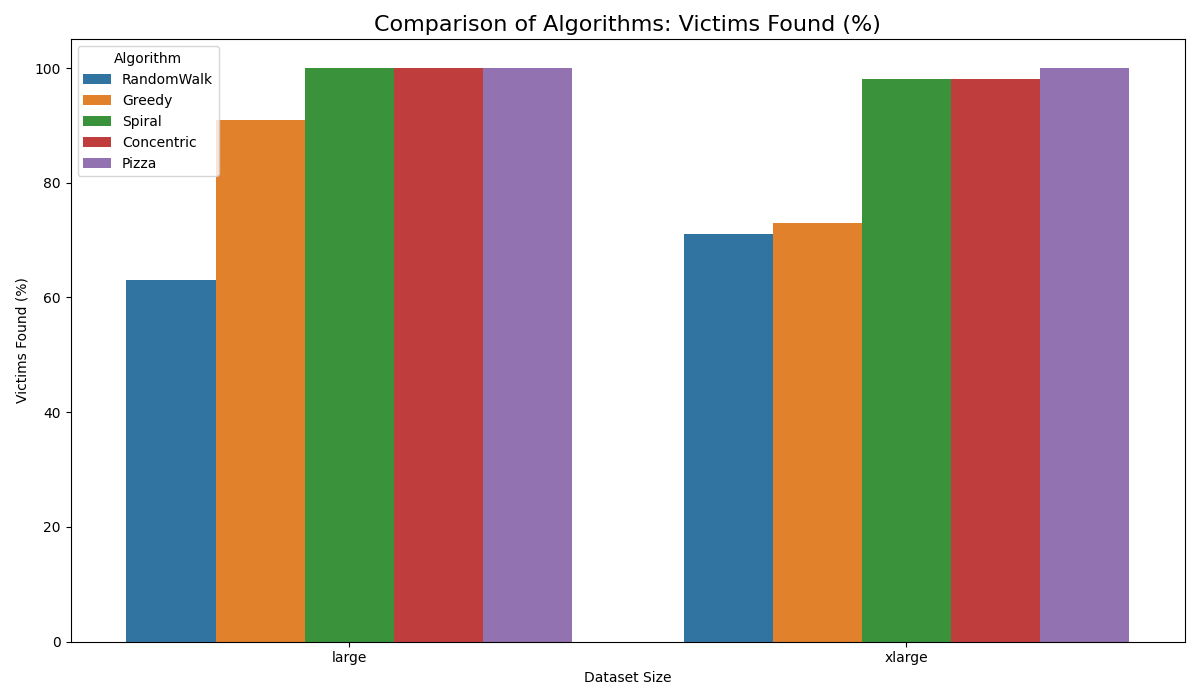

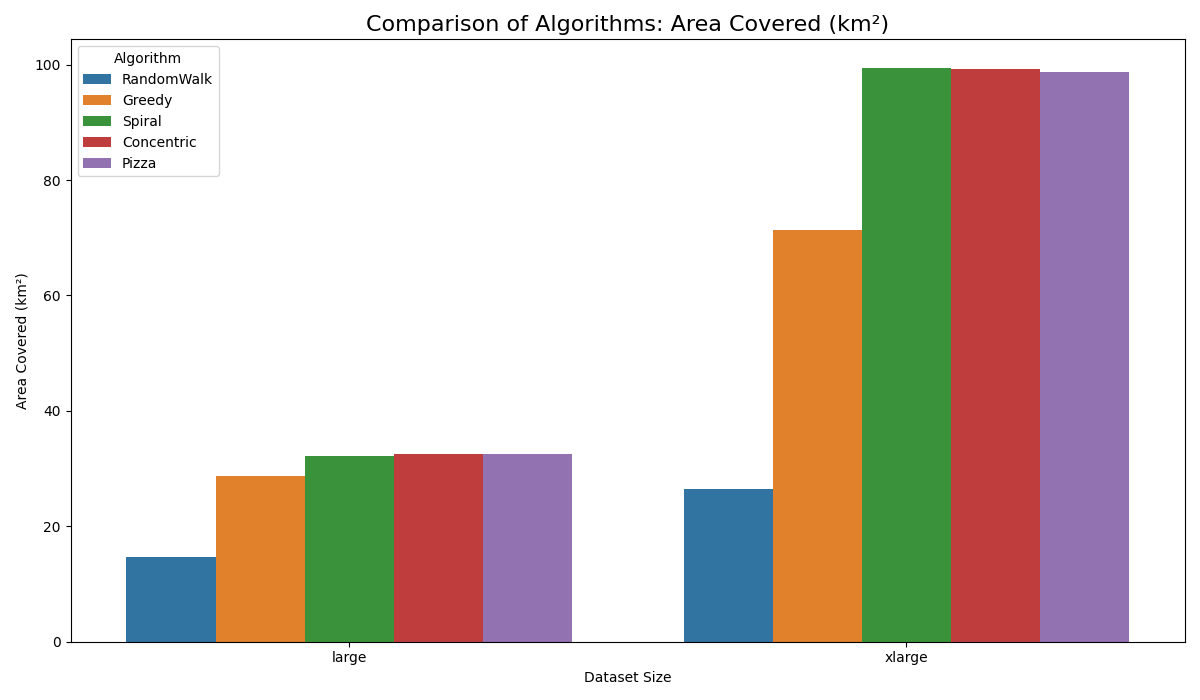


============== RESULTADOS ESTRATEGIA PUNTO LKP ==============


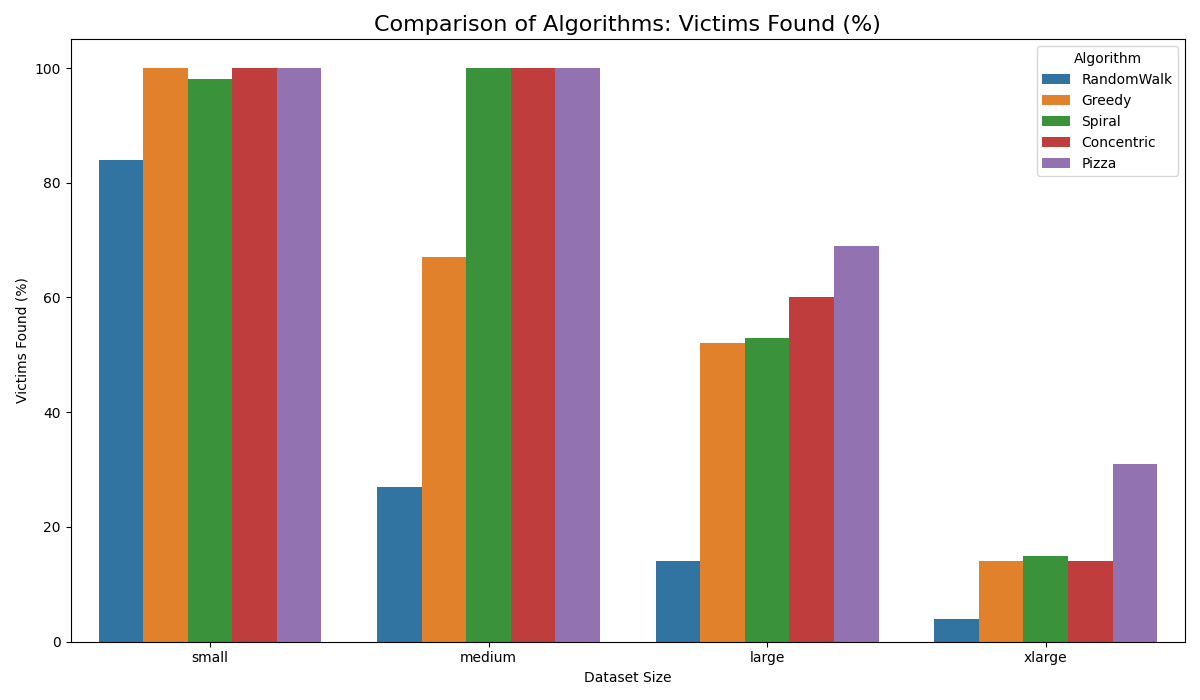

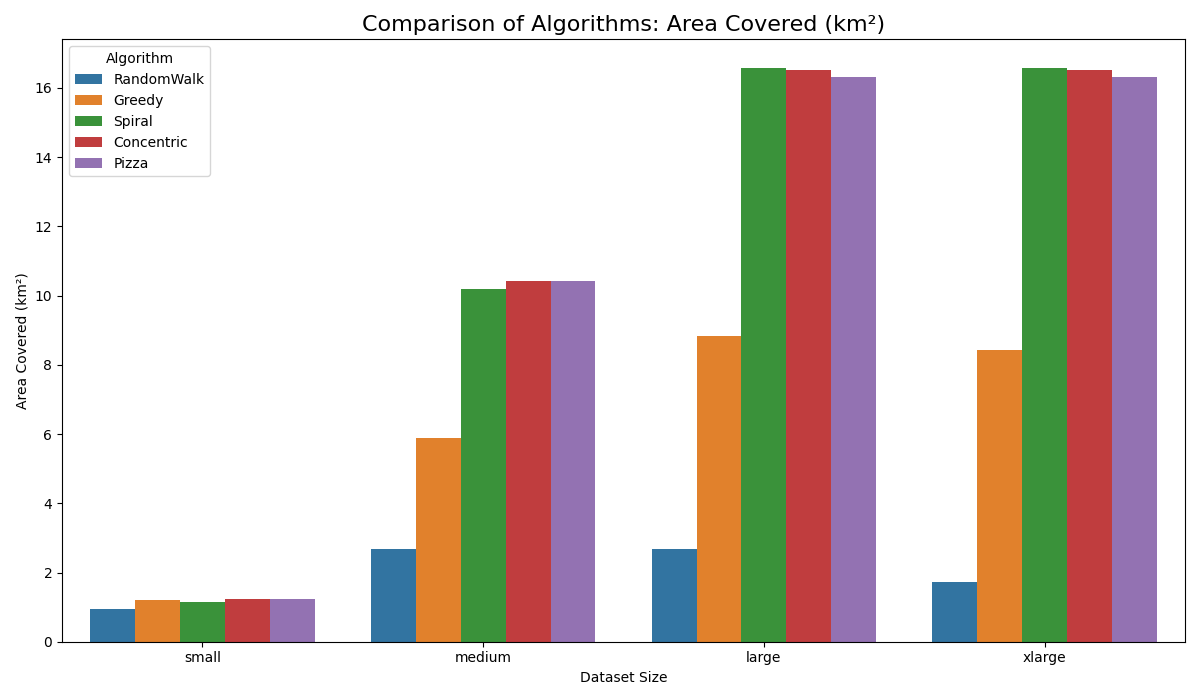

In [7]:
import os
from IPython.display import Image, display

# Gráficas del Polígono
ruta_victimas_poly = "resultados_casa_de_campo/graphs/plot_victims_found_.png"
ruta_area_poly = "resultados_casa_de_campo/graphs/plot_area_covered_(km²).png"

# Gráficas del Punto LKP
ruta_victimas_punto = "resultados_casa_de_campo_punto/graphs/plot_victims_found_.png"
ruta_area_punto = "resultados_casa_de_campo_punto/graphs/plot_area_covered_(km²).png"

print("============== RESULTADOS ESTRATEGIA POLÍGONO ==============")
if os.path.exists(ruta_victimas_poly):
    display(Image(filename=ruta_victimas_poly))
if os.path.exists(ruta_area_poly):
    display(Image(filename=ruta_area_poly))

print("\n============== RESULTADOS ESTRATEGIA PUNTO LKP ==============")
if os.path.exists(ruta_victimas_punto):
    display(Image(filename=ruta_victimas_punto))
if os.path.exists(ruta_area_punto):
    display(Image(filename=ruta_area_punto))